In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"diabetes_prediction_dataset.csv")

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


**EDA**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(3854)

In [8]:
df.drop_duplicates()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [9]:
df.groupby('gender').count()

,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
gender,,,,,,,,
Female,58552,58552,58552,58552,58552,58552,58552,58552
Male,41430,41430,41430,41430,41430,41430,41430,41430
Other,18,18,18,18,18,18,18,18


In [10]:
df.groupby('smoking_history')['diabetes'].count()

smoking_history
No Info        35816
current         9286
ever            4004
former          9352
never          35095
not current     6447
Name: diabetes, dtype: int64

In [11]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [12]:
num_col=['age','hypertension','heart_disease','bmi','HbA1c_level','blood_glucose_level']


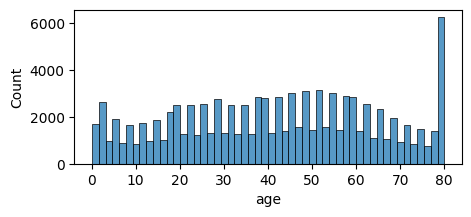

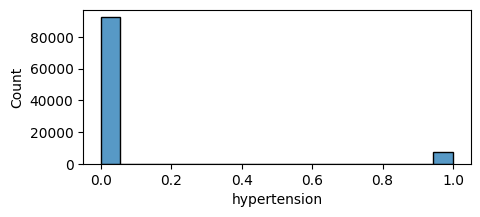

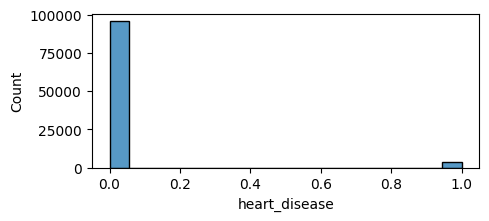

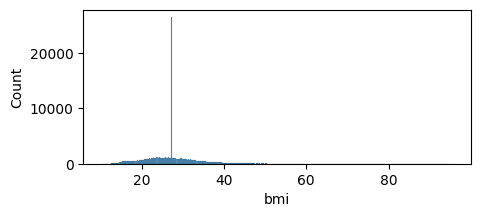

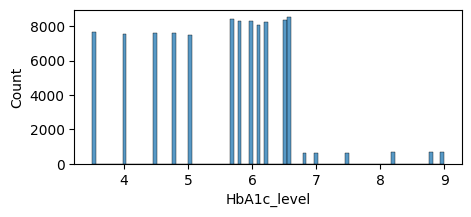

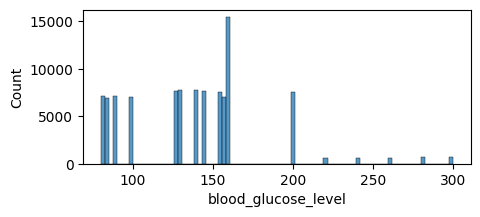

In [13]:
for i in num_col:
  plt.figure(figsize=(5,2))
  sns.histplot(df[i])
  plt.show()

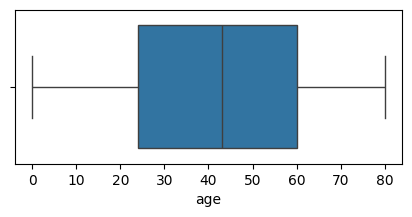

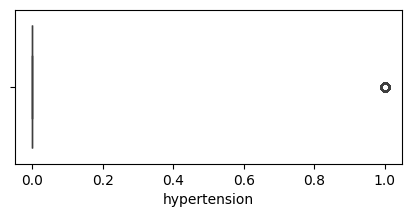

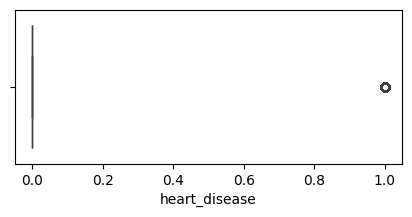

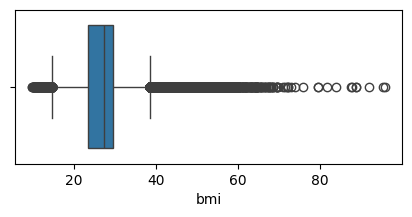

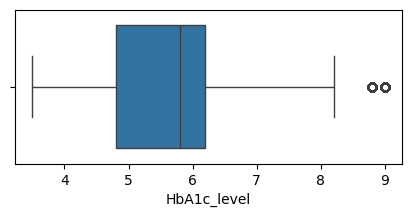

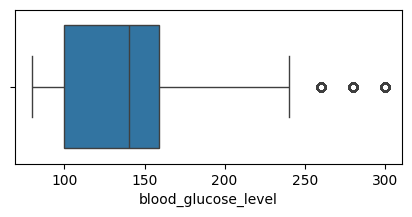

In [14]:
for i in num_col:
  plt.figure(figsize=(5,2))
  sns.boxplot(x=df[i])
  plt.show()

In [15]:
df['bmi'].value_counts()

bmi
27.32    25495
23.00      103
27.12      101
24.96      100
27.80      100
         ...  
54.29        1
55.18        1
53.41        1
11.75        1
12.77        1
Name: count, Length: 4247, dtype: int64

In [16]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]

print(f"Original DataFrame shape: (100000, 9)")
print(f"DataFrame shape after outlier removal: {df.shape}")

Original DataFrame shape: (100000, 9)
DataFrame shape after outlier removal: (92914, 9)


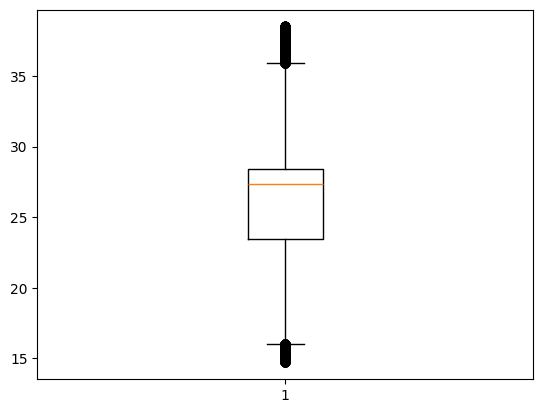

In [17]:
plt.boxplot(df['bmi'])
plt.show()

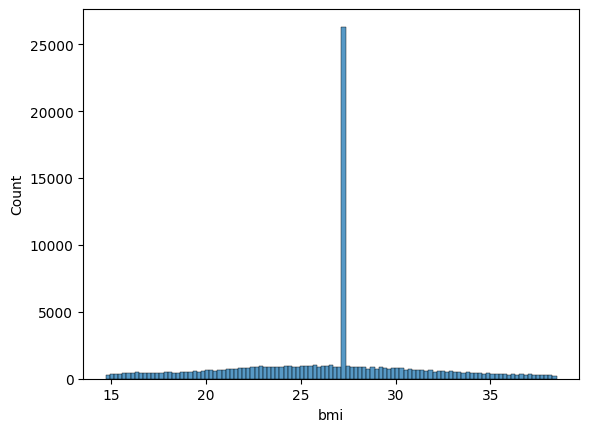

In [18]:
sns.histplot(df['bmi'])
plt.show()

In [19]:
df['bmi'].mode()

0    27.32
Name: bmi, dtype: float64

In [20]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [21]:

bins = [0, 18.5, 25.0, 30.0, float('inf')]
labels = ['Underweight', 'Normal weight', 'Overweight', 'Obesity']
df['bins'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)


In [22]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,bins
0,Female,80.0,0,1,never,25.19,6.6,140,0,Overweight
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Overweight
2,Male,28.0,0,0,never,27.32,5.7,158,0,Overweight
3,Female,36.0,0,0,current,23.45,5.0,155,0,Normal weight
4,Male,76.0,1,1,current,20.14,4.8,155,0,Normal weight


In [23]:
df.shape

(92914, 10)

In [24]:
df['bins'].value_counts()

bins
Overweight       45751
Normal weight    22219
Obesity          17571
Underweight       7373
Name: count, dtype: int64

 **Data_Preprosessing**

In [25]:
cat_cols = ['gender', 'smoking_history', 'bins']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,bins_Normal weight,bins_Overweight,bins_Obesity
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False,False,True,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False,True,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False,True,False,False


In [26]:
df=df.astype(int)

In [27]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,bins_Normal weight,bins_Overweight,bins_Obesity
0,80,0,1,25,6,140,0,0,0,0,0,0,1,0,0,1,0
1,54,0,0,27,6,80,0,0,0,0,0,0,0,0,0,1,0
2,28,0,0,27,5,158,0,1,0,0,0,0,1,0,0,1,0
3,36,0,0,23,5,155,0,0,0,1,0,0,0,0,1,0,0
4,76,1,1,20,4,155,0,1,0,1,0,0,0,0,1,0,0


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
X=df.drop('diabetes',axis=1)
y=df['diabetes']

In [30]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [31]:
X

array([[ 1.67992084, -0.27494127,  4.95944989, ..., -0.56061912,
         1.0153141 , -0.48292177],
       [ 0.53180138, -0.27494127, -0.20163527, ..., -0.56061912,
         1.0153141 , -0.48292177],
       [-0.61631807, -0.27494127, -0.20163527, ..., -0.56061912,
         1.0153141 , -0.48292177],
       ...,
       [ 1.06170267, -0.27494127, -0.20163527, ..., -0.56061912,
         1.0153141 , -0.48292177],
       [-0.79295184, -0.27494127, -0.20163527, ..., -0.56061912,
        -0.98491689,  2.07072876],
       [ 0.66427671, -0.27494127, -0.20163527, ...,  1.78374223,
        -0.98491689, -0.48292177]])

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay

In [34]:
LOReg_Model=LogisticRegression()
LOReg_Model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
LOReg_Model.score(X_train,y_train)

0.9621056351603161

In [36]:
y_pred = LOReg_Model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[28148   235]
 [  920  1359]]


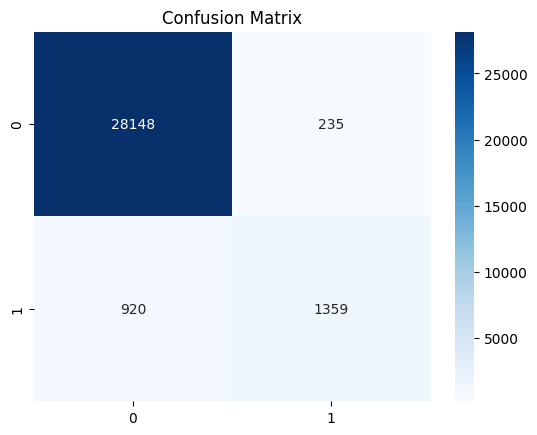

In [37]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [38]:
f1_score = accuracy_score(y_test, y_pred)
print(f"F1 Score: {f1_score}")

F1 Score: 0.9623312243167439


In [39]:
from sklearn.metrics import precision_score, recall_score

In [40]:
recall=recall_score(y_test, y_pred)
print(f"Recall Score: {recall}")

Recall Score: 0.5963141728828434


In [41]:
precision=precision_score(y_test, y_pred)
print(f"Precision Score: {precision}")

Precision Score: 0.8525721455457967


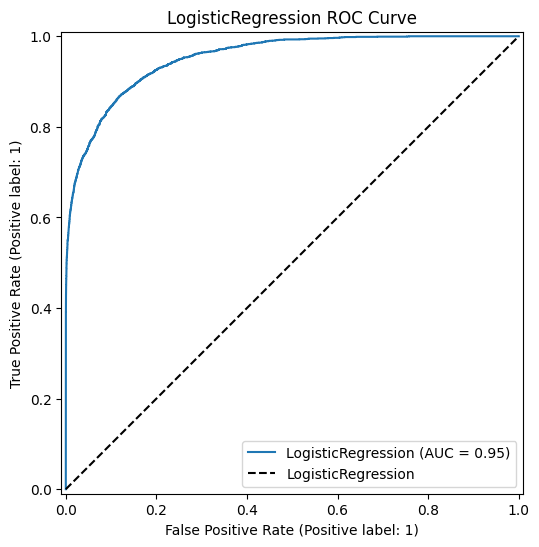

In [42]:
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(LOReg_Model, X_test, y_test, ax=plt.gca())
plt.title('LogisticRegression ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='LogisticRegression')
plt.legend()
plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
RF_Model=RandomForestClassifier()
RF_Model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:

y_pred_rf = RF_Model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9671254321309765
Random Forest Confusion Matrix:
 [[28168   215]
 [  793  1486]]


Random Forest Accuracy: 0.9671
Random Forest Precision: 0.8736
Random Forest Recall: 0.6520
Random Forest F1-Score: 0.7467
Random Forest ROC-AUC Score: 0.8222


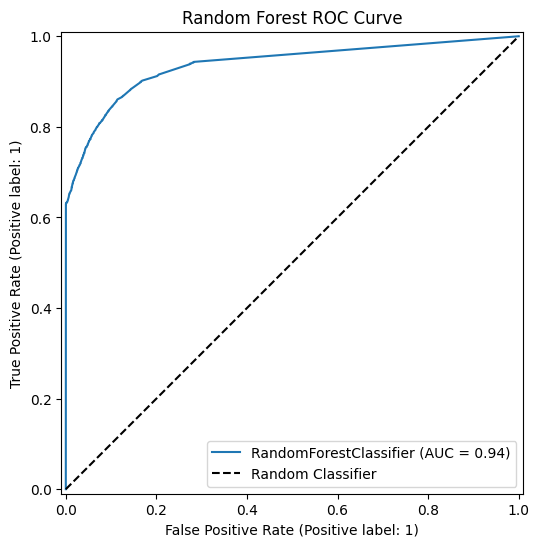

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Accuracy (already printed, but including for completeness)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# Precision
precision_rf = precision_score(y_test, y_pred_rf)
print(f"Random Forest Precision: {precision_rf:.4f}")

# Recall
recall_rf = recall_score(y_test, y_pred_rf)
print(f"Random Forest Recall: {recall_rf:.4f}")

# F1-Score
f1_rf = f1_score(y_test, y_pred_rf)
print(f"Random Forest F1-Score: {f1_rf:.4f}")

# ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)
print(f"Random Forest ROC-AUC Score: {roc_auc_rf:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(RF_Model, X_test, y_test, ax=plt.gca())
plt.title('Random Forest ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

In [47]:
from sklearn.svm import SVC

In [48]:
SVM_Model=SVC()
SVM_Model.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [49]:
y_pred_SVM = SVM_Model.predict(X_test)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_SVM)}")
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_SVM))

SVM Accuracy: 0.969408388232992
SVM Confusion Matrix:
 [[28358    25]
 [  913  1366]]


SVM Accuracy: 0.9694
SVM Precision: 0.9820
SVM Recall: 0.5994
SVM F1-Score: 0.7444
SVM ROC-AUC Score: 0.7993


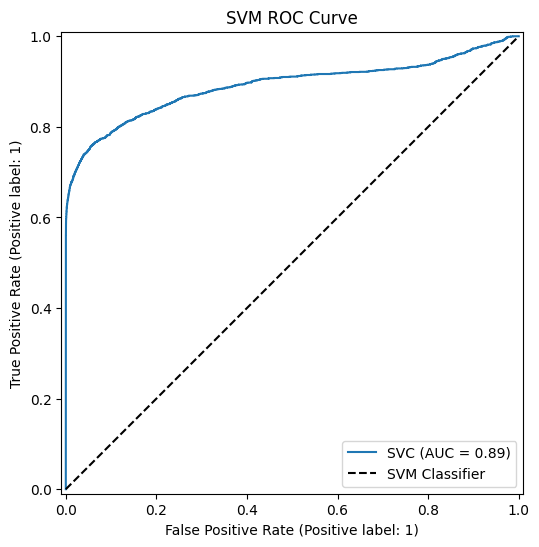

In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Accuracy (already printed, but including for completeness)
accuracy_SVM = accuracy_score(y_test, y_pred_SVM)
print(f"SVM Accuracy: {accuracy_SVM:.4f}")

# Precision
precision_SVM = precision_score(y_test, y_pred_SVM)
print(f"SVM Precision: {precision_SVM:.4f}")

# Recall
recall_SVM = recall_score(y_test, y_pred_SVM)
print(f"SVM Recall: {recall_SVM:.4f}")

# F1-Score
f1_SVM = f1_score(y_test, y_pred_SVM)
print(f"SVM F1-Score: {f1_SVM:.4f}")

# ROC-AUC Score
roc_auc_SVM = roc_auc_score(y_test, y_pred_SVM)
print(f"SVM ROC-AUC Score: {roc_auc_SVM:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(SVM_Model, X_test, y_test, ax=plt.gca())
plt.title('SVM ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='SVM Classifier')
plt.legend()
plt.show()

In [51]:
df['diabetes'].value_counts()

diabetes
0    85892
1     7022
Name: count, dtype: int64

## XGBoost Model

In [52]:
from xgboost import XGBClassifier

XGB_Model = XGBClassifier()
XGB_Model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [53]:
y_pred_xgb = XGB_Model.predict(X_test)

print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9705498662839998
XGBoost Confusion Matrix:
 [[28287    96]
 [  807  1472]]


XGBoost Accuracy: 0.9705
XGBoost Precision: 0.9388
XGBoost Recall: 0.6459
XGBoost F1-Score: 0.7653
XGBoost ROC-AUC Score: 0.8213


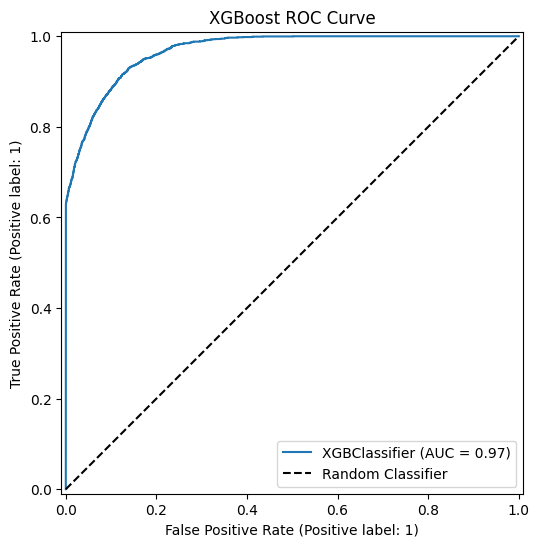

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Accuracy (already printed, but including for completeness)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

# Precision
precision_xgb = precision_score(y_test, y_pred_xgb)
print(f"XGBoost Precision: {precision_xgb:.4f}")

# Recall
recall_xgb = recall_score(y_test, y_pred_xgb)
print(f"XGBoost Recall: {recall_xgb:.4f}")

# F1-Score
f1_xgb = f1_score(y_test, y_pred_xgb)
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

# ROC-AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)
print(f"XGBoost ROC-AUC Score: {roc_auc_xgb:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(XGB_Model, X_test, y_test, ax=plt.gca())
plt.title('XGBoost ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

**New_threshold**

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression Metrics (correcting F1-score and adding ROC-AUC)
y_pred_lr = LOReg_Model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
# LogisticRegression does not have predict_proba directly on the model, need decision_function or calibrate if available
# For simplicity, using predicted labels for ROC-AUC here, but typically probabilities are preferred.
roc_auc_lr = roc_auc_score(y_test, y_pred_lr)

# Random Forest Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)

# SVM Metrics
accuracy_SVM = accuracy_score(y_test, y_pred_SVM)
precision_SVM = precision_score(y_test, y_pred_SVM)
recall_SVM = recall_score(y_test, y_pred_SVM)
f1_SVM = f1_score(y_test, y_pred_SVM)
roc_auc_SVM = roc_auc_score(y_test, y_pred_SVM)

# XGBoost Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)

# Create a dictionary to store the results
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_SVM, accuracy_xgb],
    'Precision': [precision_lr, precision_rf, precision_SVM, precision_xgb],
    'Recall': [recall_lr, recall_rf, recall_SVM, recall_xgb],
    'F1-Score': [f1_lr, f1_rf, f1_SVM, f1_xgb],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_SVM, roc_auc_xgb]
}

# Create a DataFrame from the results dictionary
df_results = pd.DataFrame(results)

# Display the DataFrame
print("\n--- Model Performance Comparison ---\n")
print(df_results.round(4))



--- Model Performance Comparison ---

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.9623     0.8526  0.5963    0.7018   0.7940
1        Random Forest    0.9671     0.8736  0.6520    0.7467   0.8222
2                  SVM    0.9694     0.9820  0.5994    0.7444   0.7993
3              XGBoost    0.9705     0.9388  0.6459    0.7653   0.8213


In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the new decision threshold
new_threshold = 0.3

# --- Logistic Regression ---
# Get prediction probabilities for the positive class
y_proba_lr = LOReg_Model.predict_proba(X_test)[:, 1]
# Apply the new threshold
y_pred_lr_new = (y_proba_lr >= new_threshold).astype(int)

accuracy_lr_new = accuracy_score(y_test, y_pred_lr_new)
precision_lr_new = precision_score(y_test, y_pred_lr_new)
recall_lr_new = recall_score(y_test, y_pred_lr_new)
f1_lr_new = f1_score(y_test, y_pred_lr_new)
roc_auc_lr_new = roc_auc_score(y_test, y_proba_lr) # ROC-AUC uses probabilities, not thresholded predictions

# --- Random Forest ---
y_proba_rf = RF_Model.predict_proba(X_test)[:, 1]
y_pred_rf_new = (y_proba_rf >= new_threshold).astype(int)

accuracy_rf_new = accuracy_score(y_test, y_pred_rf_new)
precision_rf_new = precision_score(y_test, y_pred_rf_new)
recall_rf_new = recall_score(y_test, y_pred_rf_new)
f1_rf_new = f1_score(y_test, y_pred_rf_new)
roc_auc_rf_new = roc_auc_score(y_test, y_proba_rf)

# --- XGBoost ---
y_proba_xgb = XGB_Model.predict_proba(X_test)[:, 1]
y_pred_xgb_new = (y_proba_xgb >= new_threshold).astype(int)

accuracy_xgb_new = accuracy_score(y_test, y_pred_xgb_new)
precision_xgb_new = precision_score(y_test, y_pred_xgb_new)
recall_xgb_new = recall_score(y_test, y_pred_xgb_new)
f1_xgb_new = f1_score(y_test, y_pred_xgb_new)
roc_auc_xgb_new = roc_auc_score(y_test, y_proba_xgb)

# Create a dictionary to store the results with the new threshold
results_new_threshold = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr_new, accuracy_rf_new, accuracy_xgb_new],
    'Precision': [precision_lr_new, precision_rf_new, precision_xgb_new],
    'Recall': [recall_lr_new, recall_rf_new, recall_xgb_new],
    'F1-Score': [f1_lr_new, f1_rf_new, f1_xgb_new],
    'ROC-AUC': [roc_auc_lr_new, roc_auc_rf_new, roc_auc_xgb_new]
}

# Create a DataFrame from the results dictionary
df_results_new = pd.DataFrame(results_new_threshold)

print(f"--- Model Performance Comparison with Decision Threshold = {new_threshold} ---\n")
print(df_results_new.round(4))

print("\n--- Original Model Performance Comparison (for reference) ---\n")
print(df_results.round(4))


--- Model Performance Comparison with Decision Threshold = 0.3 ---

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.9549     0.6995  0.6893    0.6944   0.9529
1        Random Forest    0.9556     0.7015  0.7003    0.7009   0.9375
2              XGBoost    0.9625     0.7766  0.6955    0.7338   0.9688

--- Original Model Performance Comparison (for reference) ---

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.9623     0.8526  0.5963    0.7018   0.7940
1        Random Forest    0.9671     0.8736  0.6520    0.7467   0.8222
2                  SVM    0.9694     0.9820  0.5994    0.7444   0.7993
3              XGBoost    0.9705     0.9388  0.6459    0.7653   0.8213


**class_weight='balanced'**



In [57]:


# Calculate scale_pos_weight for XGBoost
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_val = neg_count / pos_count

# --- Train models with class_weight='balanced' or scale_pos_weight ---

# Logistic Regression
LOReg_Model_balanced = LogisticRegression(class_weight='balanced', random_state=42)
LOReg_Model_balanced.fit(X_train, y_train)
y_pred_lr_bal = LOReg_Model_balanced.predict(X_test)
y_proba_lr_bal = LOReg_Model_balanced.predict_proba(X_test)[:, 1]

# Random Forest
RF_Model_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
RF_Model_balanced.fit(X_train, y_train)
y_pred_rf_bal = RF_Model_balanced.predict(X_test)
y_proba_rf_bal = RF_Model_balanced.predict_proba(X_test)[:, 1]


# XGBoost
XGB_Model_balanced = XGBClassifier(scale_pos_weight=scale_pos_weight_val, enable_categorical=True, random_state=42)
XGB_Model_balanced.fit(X_train, y_train)
y_pred_xgb_bal = XGB_Model_balanced.predict(X_test)
y_proba_xgb_bal = XGB_Model_balanced.predict_proba(X_test)[:, 1]

# --- Evaluate and store metrics ---

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
y_preds = [y_pred_lr_bal, y_pred_rf_bal,  y_pred_xgb_bal]
y_probas = [y_proba_lr_bal, y_proba_rf_bal, y_proba_xgb_bal]

balanced_results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': []
}

for i, model_name in enumerate(models):
    balanced_results['Model'].append(model_name)
    balanced_results['Accuracy'].append(accuracy_score(y_test, y_preds[i]))
    balanced_results['Precision'].append(precision_score(y_test, y_preds[i]))
    balanced_results['Recall'].append(recall_score(y_test, y_preds[i]))
    balanced_results['F1-Score'].append(f1_score(y_test, y_preds[i]))
    balanced_results['ROC-AUC'].append(roc_auc_score(y_test, y_probas[i]))

df_balanced_results = pd.DataFrame(balanced_results)

print("--- Model Performance Comparison with Class Weight Balanced ---\n")
print(df_balanced_results.round(4))

print("\n--- Original Model Performance Comparison (for reference) ---\n")
print(df_results.round(4))

--- Model Performance Comparison with Class Weight Balanced ---

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8825     0.3750  0.8710    0.5243   0.9535
1        Random Forest    0.9642     0.8257  0.6569    0.7317   0.9396
2              XGBoost    0.9092     0.4429  0.8570    0.5839   0.9673

--- Original Model Performance Comparison (for reference) ---

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.9623     0.8526  0.5963    0.7018   0.7940
1        Random Forest    0.9671     0.8736  0.6520    0.7467   0.8222
2                  SVM    0.9694     0.9820  0.5994    0.7444   0.7993
3              XGBoost    0.9705     0.9388  0.6459    0.7653   0.8213


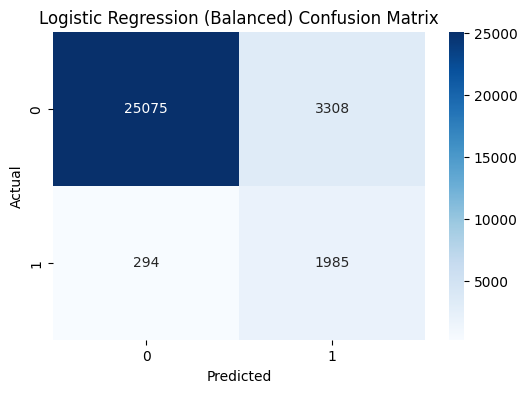

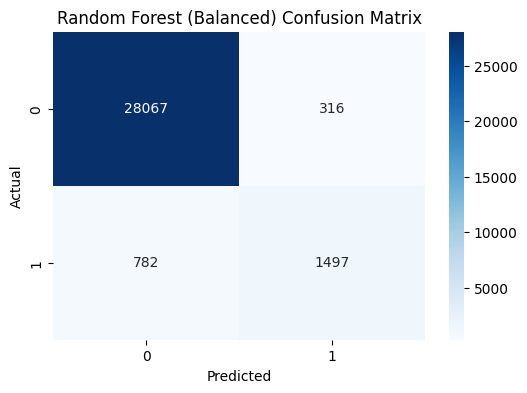

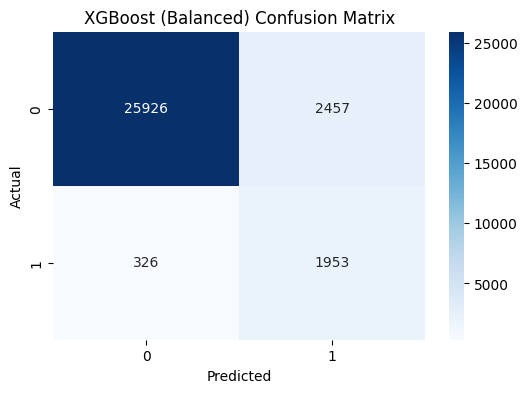

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix for Logistic Regression (balanced)
y_pred_lr_bal = LOReg_Model_balanced.predict(X_test)
cm_lr_bal = confusion_matrix(y_test, y_pred_lr_bal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr_bal, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression (Balanced) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Random Forest (balanced)
y_pred_rf_bal = RF_Model_balanced.predict(X_test)
cm_rf_bal = confusion_matrix(y_test, y_pred_rf_bal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_bal, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest (Balanced) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for XGBoost (balanced)
y_pred_xgb_bal = XGB_Model_balanced.predict(X_test)
cm_xgb_bal = confusion_matrix(y_test, y_pred_xgb_bal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb_bal, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost (Balanced) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [61]:
# ==============================================================
# Ye cell apne notebook me XGB_Model_balanced train hone ke BAAD
# aur model save karne wale cell ke jagah (ya baad me) chalayein.
# Isse model ke saath scaler aur column order bhi save ho jayega,
# jo Streamlit app ke liye zaroori hai.
# ==============================================================

import joblib

# 1) Trained XGBoost (balanced) model
joblib.dump(XGB_Model_balanced, 'xgboost_balanced_model.joblib')

# 2) StandardScaler (fit_transform X pe jo already fit ho chuka hai)
joblib.dump(scaler, 'scaler.joblib')

# 3) Training ke time X (dummies ke baad) me jo columns aur unka
#    order tha, wo save karo. Ye X = df.drop('diabetes', axis=1)
#    ke turant baad, scaler.fit_transform se PEHLE wale columns hain.
#    (Notebook me X banate waqt hi ye list bhi bana lete hain)
training_columns = list(df.drop('diabetes', axis=1).columns)
joblib.dump(training_columns, 'training_columns.joblib')

print("Saved: xgboost_balanced_model.joblib, scaler.joblib, training_columns.joblib")
print("Training columns:", training_columns)

Saved: xgboost_balanced_model.joblib, scaler.joblib, training_columns.joblib
Training columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'gender_Other', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'bins_Normal weight', 'bins_Overweight', 'bins_Obesity']
